# Cargar las liberias

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

# Cargar el dataset

In [4]:
df = pd.read_csv("C:/proyectoANN/student_model_processed.csv")

# Entrenamiento del modelo

In [5]:
# 1. Separar X e y
X = df.drop("risk_level", axis=1)
y = df["risk_level"]

In [6]:
# 2. Encodear strings en X y en y
X = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y = le.fit_transform(y)  # strings a enteros


In [7]:
# 3. Split único con stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 4. Escalar
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# 6. Modelo
model = Sequential()
model.add(Dense(units=128, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(units=64, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(units=32, activation="relu"))
model.add(Dense(units=4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [10]:
# 7. Entrenar
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=10)

model.fit(
    x=X_train,
    y=y_train,
    epochs=55,          # más épocas
    batch_size=64,      # batch más pequeño
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)






Epoch 1/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4731 - loss: 1.2521 - val_accuracy: 0.4976 - val_loss: 1.1533
Epoch 2/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5126 - loss: 1.1554 - val_accuracy: 0.5263 - val_loss: 1.1171
Epoch 3/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4874 - loss: 1.1506 - val_accuracy: 0.5837 - val_loss: 1.0886
Epoch 4/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5437 - loss: 1.0945 - val_accuracy: 0.5981 - val_loss: 1.0607
Epoch 5/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5401 - loss: 1.0595 - val_accuracy: 0.5885 - val_loss: 1.0092
Epoch 6/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5437 - loss: 1.0514 - val_accuracy: 0.6077 - val_loss: 0.9643
Epoch 7/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5533 - loss: 1.0053 - val_accuracy: 0.5981 - val_loss: 0.9350
Epoch 8/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5760 - loss: 0.9712 - val_accuracy: 0.6077 - val_loss

Loss: 0.4313
Accuracy: 0.8182


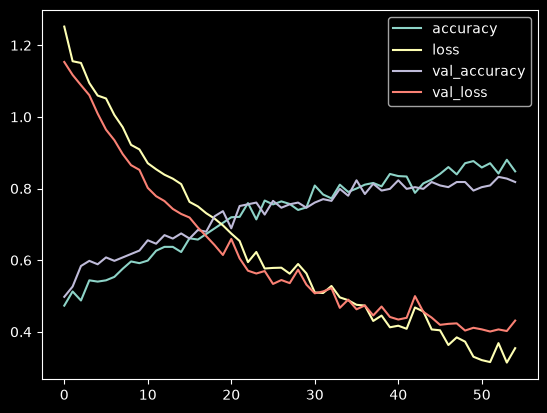

In [11]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

# Precisión final
results = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]:.4f}")

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

 Riesgo alto       0.82      0.88      0.85        16
 Riesgo bajo       0.83      0.87      0.85       104
Riesgo medio       0.61      0.67      0.63        30
  Sin riesgo       0.94      0.80      0.86        59

    accuracy                           0.82       209
   macro avg       0.80      0.80      0.80       209
weighted avg       0.83      0.82      0.82       209



# Evaluacion del modelo

In [13]:
from sklearn.metrics import classification_report,confusion_matrix

# Prediccion sobre el conjunto test

In [14]:
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [15]:
y_test

array([1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 0, 3, 1, 1, 1, 2, 3, 1, 0,
       3, 0, 1, 1, 1, 3, 3, 2, 3, 1, 1, 3, 3, 1, 2, 3, 3, 2, 0, 0, 3, 1,
       1, 2, 0, 1, 3, 3, 0, 2, 1, 2, 2, 1, 3, 1, 1, 1, 3, 0, 3, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 3, 1, 1, 2, 2, 1, 2, 1, 3, 1, 3,
       1, 3, 1, 3, 2, 3, 3, 3, 3, 1, 3, 3, 1, 1, 1, 3, 3, 2, 1, 1, 3, 1,
       1, 3, 1, 2, 1, 3, 3, 3, 1, 3, 3, 1, 2, 1, 3, 1, 3, 3, 3, 1, 1, 1,
       1, 1, 2, 3, 3, 1, 1, 2, 3, 1, 2, 0, 3, 1, 1, 3, 1, 1, 3, 1, 0, 2,
       1, 1, 3, 1, 0, 3, 1, 1, 2, 2, 1, 2, 1, 3, 1, 3, 1, 1, 1, 3, 1, 1,
       1, 0, 1, 0, 3, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 2, 0, 2, 3, 1, 3, 1,
       0, 3, 3, 1, 1, 1, 1, 3, 1, 1, 3])

In [16]:
predictions.round(3)

array([[0.021, 0.539, 0.44 , 0.   ],
       [0.   , 0.99 , 0.009, 0.001],
       [0.   , 0.984, 0.013, 0.004],
       [0.006, 0.695, 0.297, 0.002],
       [0.001, 0.876, 0.123, 0.001],
       [0.   , 0.988, 0.005, 0.007],
       [0.   , 0.888, 0.109, 0.002],
       [0.042, 0.364, 0.594, 0.001],
       [0.   , 0.922, 0.075, 0.003],
       [0.007, 0.265, 0.728, 0.   ],
       [0.   , 0.737, 0.262, 0.   ],
       [0.   , 0.979, 0.002, 0.019],
       [0.   , 0.992, 0.004, 0.003],
       [0.443, 0.017, 0.54 , 0.   ],
       [0.   , 0.039, 0.   , 0.961],
       [0.   , 0.981, 0.013, 0.006],
       [0.   , 0.948, 0.007, 0.045],
       [0.   , 0.959, 0.006, 0.035],
       [0.006, 0.589, 0.405, 0.   ],
       [0.   , 0.074, 0.   , 0.926],
       [0.   , 0.979, 0.002, 0.019],
       [0.934, 0.001, 0.066, 0.   ],
       [0.   , 0.104, 0.   , 0.896],
       [0.658, 0.004, 0.338, 0.   ],
       [0.   , 0.948, 0.051, 0.   ],
       [0.002, 0.78 , 0.217, 0.001],
       [0.   , 0.83 , 0.003, 0.167],
 

In [17]:
predictions_lab = np.argmax(model.predict(X_test), axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [18]:
predictions_lab

array([1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 3, 1, 1, 1, 1, 3, 1, 0,
       3, 0, 1, 1, 1, 3, 3, 2, 1, 1, 1, 3, 3, 1, 2, 3, 3, 2, 0, 0, 1, 1,
       1, 2, 0, 1, 3, 3, 0, 1, 1, 2, 2, 1, 3, 1, 1, 1, 1, 0, 3, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 3, 1, 1, 1, 2, 1, 2, 1, 3, 1, 1,
       2, 3, 2, 3, 0, 3, 3, 3, 3, 1, 3, 3, 1, 3, 1, 3, 3, 0, 1, 1, 1, 1,
       1, 3, 1, 2, 2, 3, 3, 3, 1, 3, 3, 1, 2, 2, 1, 3, 3, 3, 3, 1, 1, 1,
       1, 1, 2, 3, 3, 1, 1, 2, 3, 1, 0, 2, 1, 1, 1, 1, 1, 1, 3, 1, 0, 1,
       1, 1, 3, 1, 0, 3, 1, 1, 2, 2, 1, 2, 1, 3, 1, 3, 2, 1, 2, 3, 2, 1,
       1, 0, 2, 0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 3, 1, 2, 0, 1, 1, 1, 1, 1,
       0, 3, 3, 1, 1, 1, 1, 3, 2, 2, 1])

In [19]:
predictions_lab_real = predictions_lab+1

In [20]:
predictions_lab_real

array([2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 3, 4, 2, 2, 2, 2, 4, 2, 1,
       4, 1, 2, 2, 2, 4, 4, 3, 2, 2, 2, 4, 4, 2, 3, 4, 4, 3, 1, 1, 2, 2,
       2, 3, 1, 2, 4, 4, 1, 2, 2, 3, 3, 2, 4, 2, 2, 2, 2, 1, 4, 2, 2, 3,
       2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 4, 4, 2, 2, 2, 3, 2, 3, 2, 4, 2, 2,
       3, 4, 3, 4, 1, 4, 4, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 1, 2, 2, 2, 2,
       2, 4, 2, 3, 3, 4, 4, 4, 2, 4, 4, 2, 3, 3, 2, 4, 4, 4, 4, 2, 2, 2,
       2, 2, 3, 4, 4, 2, 2, 3, 4, 2, 1, 3, 2, 2, 2, 2, 2, 2, 4, 2, 1, 2,
       2, 2, 4, 2, 1, 4, 2, 2, 3, 3, 2, 3, 2, 4, 2, 4, 3, 2, 3, 4, 3, 2,
       2, 1, 3, 1, 2, 2, 2, 2, 1, 2, 2, 2, 3, 4, 2, 3, 1, 2, 2, 2, 2, 2,
       1, 4, 4, 2, 2, 2, 2, 4, 3, 3, 2])

In [21]:
y_prob = model.predict(X_test)
df_test_lab = pd.DataFrame(y_prob, columns=le.classes_).round(4)
df_test_lab['prediccion'] = le.inverse_transform(np.argmax(y_prob, axis=1))
df_test_lab

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Riesgo alto,Riesgo bajo,Riesgo medio,Sin riesgo,prediccion
0,0.0208,0.5388,0.4400,0.0003,Riesgo bajo
1,0.0000,0.9904,0.0086,0.0010,Riesgo bajo
2,0.0000,0.9837,0.0127,0.0036,Riesgo bajo
3,0.0064,0.6945,0.2971,0.0020,Riesgo bajo
4,0.0006,0.8758,0.1227,0.0009,Riesgo bajo
...,...,...,...,...,...
204,0.0027,0.6754,0.3214,0.0005,Riesgo bajo
205,0.0000,0.0584,0.0000,0.9416,Sin riesgo
206,0.0478,0.3413,0.6101,0.0008,Riesgo medio
207,0.0261,0.3177,0.6557,0.0006,Riesgo medio


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Confusion matrix sin normalizar
[[14  0  2  0]
 [ 0 90 11  3]
 [ 3  7 20  0]
 [ 0 12  0 47]]
Normalized confusion matrix
[[0.88 0.   0.12 0.  ]
 [0.   0.87 0.11 0.03]
 [0.1  0.23 0.67 0.  ]
 [0.   0.2  0.   0.8 ]]


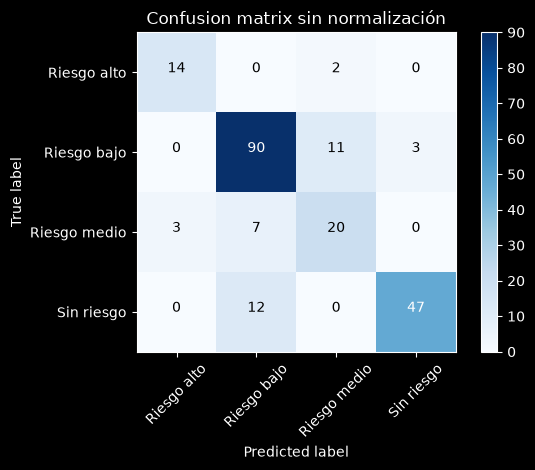

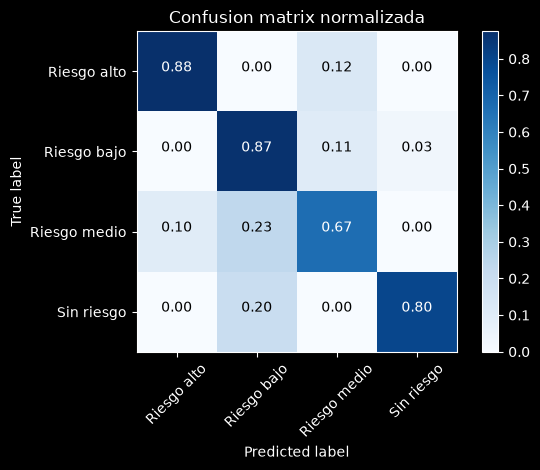

In [22]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix sin normalizar')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

# Clases y predicciones
clases = le.classes_
y_pred = np.argmax(model.predict(X_test), axis=1)

cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Sin normalizar
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=clases,
                      title='Confusion matrix sin normalización')

# Normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=clases,
                      normalize=True,
                      title='Confusion matrix normalizada')
plt.show()

# Prediccion con nuevos datos

In [23]:
#Pediccion nuevos datos
# Tomamos los datos originales sin la columna objetivo
df_pred = df[df.columns.drop('risk_level')].copy()

# get_dummies igual que en entrenamiento
df_pred_dum = pd.get_dummies(df_pred, drop_first=True)
df_pred_dum = df_pred_dum.reindex(columns=X.columns, fill_value=0)

# Escalar
X_pred = scaler.transform(df_pred_dum)

# Predicción
y_prob_pred = model.predict(X_pred)
y_pred_clases = le.inverse_transform(np.argmax(y_prob_pred, axis=1))

# Unir predicción con datos originales
df_pred['PREDICCIÓN'] = y_pred_clases
df_pred

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,subject,G3,PREDICCIÓN
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,math,6,Riesgo alto
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,math,6,Riesgo alto
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,math,10,Riesgo medio
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,math,15,Sin riesgo
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,math,10,Riesgo bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,MS,F,19,R,GT3,T,2,3,services,other,...,2,1,2,5,4,10,11,portuguese,10,Riesgo bajo
1040,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,1,1,1,4,15,15,portuguese,16,Sin riesgo
1041,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,5,6,11,12,portuguese,9,Riesgo bajo
1042,MS,M,17,U,LE3,T,3,1,services,services,...,5,3,4,2,6,10,10,portuguese,10,Riesgo bajo


In [27]:
#Guardar y cargar el modelo para posterior uso
from tensorflow.keras.models import load_model
import pickle

# 1. Modelo
model.save('modelo_riesgo.keras')

# 2. Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. LabelEncoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [28]:
import os
print(os.getcwd())

C:\JupyterProject1
